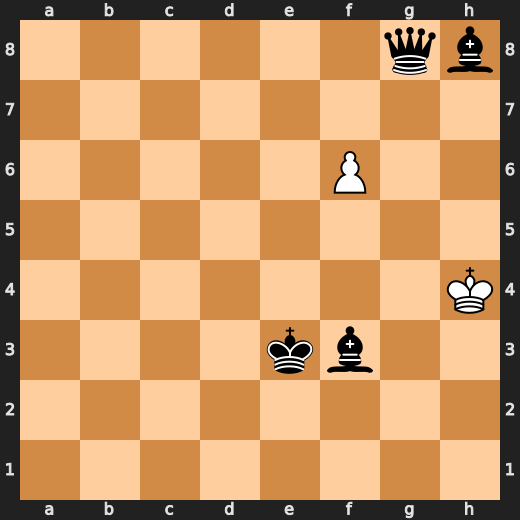


ENGINE COLOR: WHITE
StockFish COLOR: BLACK
RESULT: ?
WINNER: UNKNOWN
TOTAL MOVES: 73

FEN:
6qb/8/5P2/8/7K/4kb2/8/8 w - - 1 73

===== STOCKFISH EVAL =====
Stockfish: BLACK mate in 2
Better side: BLACK


In [3]:
import chess
import chess.svg
from IPython.display import display
import chess
import chess.engine
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

STOCKFISH_PATH = r"D:\Chess by Imre Harmos\stockfish-windows-x86-64-avx2\stockfish\stockfish-windows-x86-64-avx2.exe"


#for tracking moves and result from elo calculator logs (when it is not showing the board)


log_text = """



==============================
TESTING vs STOCKFISH ELO: 1660
==============================

GAME 1/6 vs SF 1660  engine: WHITE
engine: e2e4
sf: e7e5
engine: g1f3
sf: g8f6
engine: f3e5
sf: d7d6
engine: e5f3
sf: f8e7
engine: d2d4
sf: f6e4
engine: c2c4
sf: c7c5
engine: f1d3
sf: f7f5
engine: e1g1
sf: b8c6
engine: d1a4
sf: c8d7
engine: a4b3
sf: c6d4
engine: f3d4
sf: c5d4
engine: b1d2
sf: d7c6
engine: b3c2
sf: e4c5
engine: d3f5
sf: g7g6
engine: f5g4
sf: e7f6
engine: f1e1
sf: e8f7
engine: d2b3
sf: f7g7
engine: b3c5
sf: d6c5
engine: c2b1
sf: h7h5
engine: g4d1
sf: d4d3
engine: c1d2
sf: f6d4
engine: g2g3
sf: d8f6
engine: d2f4
sf: d4b2
engine: f4g5
sf: f6c3
engine: e1e7
sf: g7g8
engine: d1e2
sf: a8e8
engine: e7e8
sf: c6e8
engine: e2d3
sf: g8g7
engine: g5e3
sf: e8f7
engine: d3f1
sf: b7b6
engine: g3g4
sf: c3e5
engine: g4h5
sf: h8h5
engine: e3f4
sf: e5f6
engine: f1e2
sf: b2a1
engine: e2h5
sf: a1d4
engine: b1e4
sf: g6h5
engine: e4g2
sf: f6g6
engine: f4d6
sf: b6b5
engine: c4b5
sf: g6g2
engine: g1g2
sf: g7g8
engine: d6b8
sf: f7d5
engine: g2g3
sf: g8f7
engine: b8a7
sf: d5a2
engine: f2f4
sf: f7g6
engine: a7b8
sf: g6f5
engine: b8c7
sf: a2d5
engine: g3h4
sf: c5c4
engine: h4h5
sf: d5g8
engine: h2h3
sf: c4c3
engine: b5b6
sf: g8d5
engine: c7d6
sf: d5h1
engine: h5h6
sf: d4b6
engine: d6b4
sf: b6d4
engine: h3h4
sf: c3c2
engine: b4d2
sf: f5g4
engine: h4h5
sf: h1c6
engine: h6g6
sf: c6e8
engine: g6h7
sf: e8f7
engine: h5h6
sf: d4b2
engine: d2e3
sf: g4f3
engine: e3d2
sf: f3e2
engine: d2c1
sf: b2c1
engine: h7g7
sf: f7c4
engine: h6h7
sf: c1b2
engine: g7h6
sf: c2c1q
engine: h7h8n
sf: b2h8
engine: h6g5
sf: c4d5
engine: g5g4
sf: e2e3
engine: g4g5
sf: c1c7
engine: f4f5
sf: c7g7
engine: g5h4
sf: g7g8
engine: f5f6
sf: d5f3
"""

moves = []
engine_color = None
result = "?"

for line in log_text.splitlines():

    line = line.strip()

    # engine color
    if line.startswith("GAME") and "engine:" in line:
        engine_color = chess.WHITE if "WHITE" in line else chess.BLACK

    # moves
    if line.startswith("sf:") or line.startswith("engine:"):
        mv = line.split(":")[1].strip()
        moves.append(mv)

    # result
    if line.startswith("RESULT"):
        result = line.split(":")[1].strip()


board = chess.Board()

for m in moves:
    try:
        board.push_uci(m)
    except:
        print("illegal skipped:", m)
        break


# ===== DISPLAY =====

display(chess.svg.board(board, size=520))

print()
print("ENGINE COLOR:", "WHITE" if engine_color else "BLACK")
print("StockFish COLOR:", "BLACK" if engine_color else "WHITE")

print("RESULT:", result)

# winner logic
winner = "UNKNOWN"

if result == "1-0":
    winner = "ENGINE" if engine_color == chess.WHITE else "STOCKFISH"

elif result == "0-1":
    winner = "ENGINE" if engine_color == chess.BLACK else "STOCKFISH"

elif result in ["1/2-1/2", "draw", "DRAW"]:
    winner = "DRAW"

print("WINNER:", winner)

print("TOTAL MOVES:", board.fullmove_number)

print("\nFEN:")
print(board.fen())

# ===== STOCKFISH EVAL =====

print("\n===== STOCKFISH EVAL =====")

engine = chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH)

info = engine.analyse(
    board,
    chess.engine.Limit(depth=20)
)

score = info["score"].pov(chess.WHITE)

if score.is_mate():
    mate = score.mate()

    if mate > 0:
        print("Stockfish: WHITE mate in", mate)
        print("Better side: WHITE")
    else:
        print("Stockfish: BLACK mate in", abs(mate))
        print("Better side: BLACK")

else:
    eval_cp = score.score() / 100
    print("Stockfish eval:", round(eval_cp, 2))

    if eval_cp > 0:

        if engine_color == chess.WHITE:
            print("Better side: IMI ENGINE")
        else:
            print("Better side: STOCKFISH")

    elif eval_cp < 0:

        if engine_color == chess.BLACK:
            print("Better side: IMI ENGINE")
        else:
            print("Better side: STOCKFISH")

    else:
        print("Position equal")

engine.quit()
